In [9]:
from __future__ import annotations

from pathlib import Path
import re
from typing import Dict, Optional


def read_simulation_time(log_file: str | Path) -> Dict[str, Optional[float]]:
    """Read simulation timing information from an md-flexible logOutput file.

    Returns a dictionary with:
    - metric: Which line was parsed ("Total wall-clock time", "Simulate", or "Total accumulated")
    - nanoseconds: Parsed time in ns (float)
    - seconds: Parsed time in s (float)
    - file: Absolute path to the parsed file
    """
    path = Path(log_file).expanduser().resolve()
    text = path.read_text(encoding="utf-8", errors="replace")

    patterns = [
        r"Total wall-clock time\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Simulate\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Total accumulated\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
    ]
    labels = ["Total wall-clock time", "Simulate", "Total accumulated"]

    for label, pattern in zip(labels, patterns):
        match = re.search(pattern, text)
        if match:
            return {
                "metric": label,
                "nanoseconds": float(match.group(1)),
                "seconds": float(match.group(2)),
                "file": str(path),
            }

    raise ValueError(
        f"No known simulation-time pattern found in {path}. Expected one of: "
        "'Total wall-clock time', 'Simulate', or 'Total accumulated'."
    )


# Example:
# result = read_simulation_time(
#     "generated_inputs_rangeCheck/totalParticles_300000/sigmaRatio_0p15/countRatio_2p00/dataLayout_AoS/run_0/logOutput_155157_2.out"
# )
# print(result)


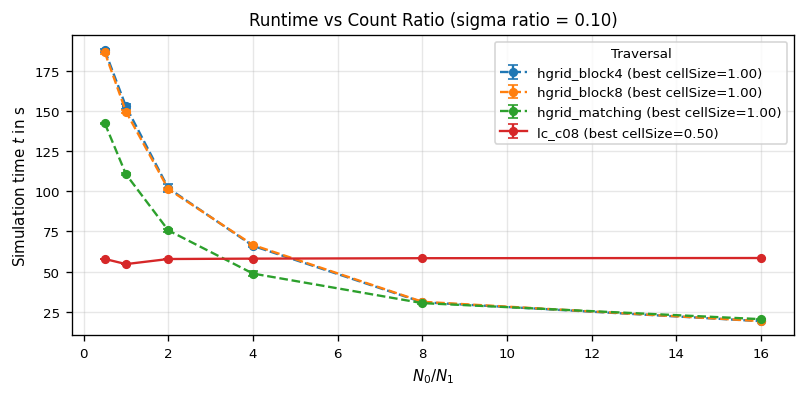

Saved: ../thesis_plots/comparison_sigma_0p10.pdf


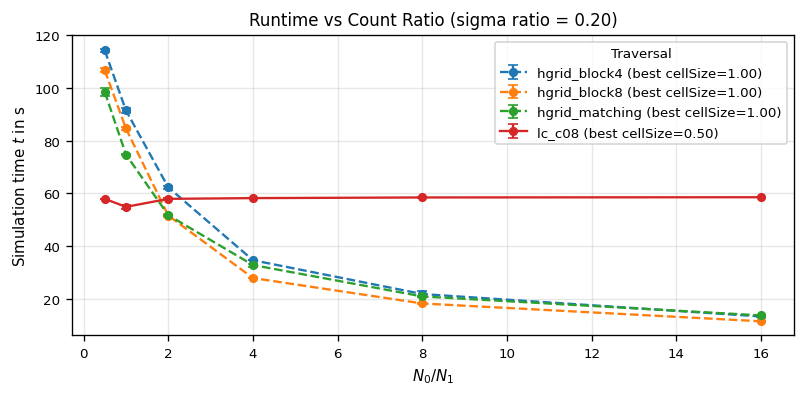

Saved: ../thesis_plots/comparison_sigma_0p20.pdf


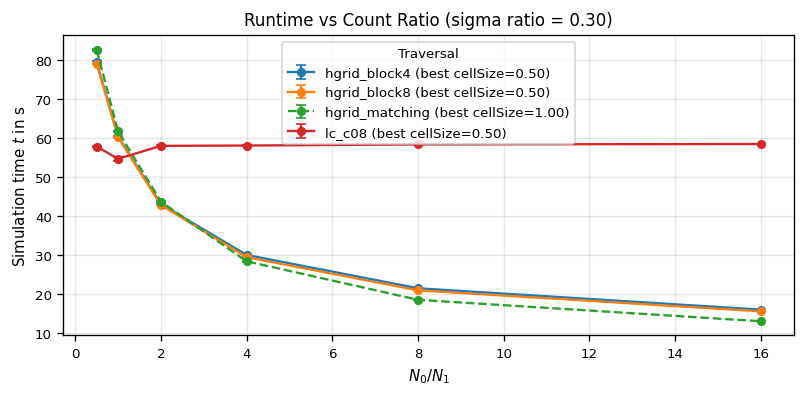

Saved: ../thesis_plots/comparison_sigma_0p30.pdf


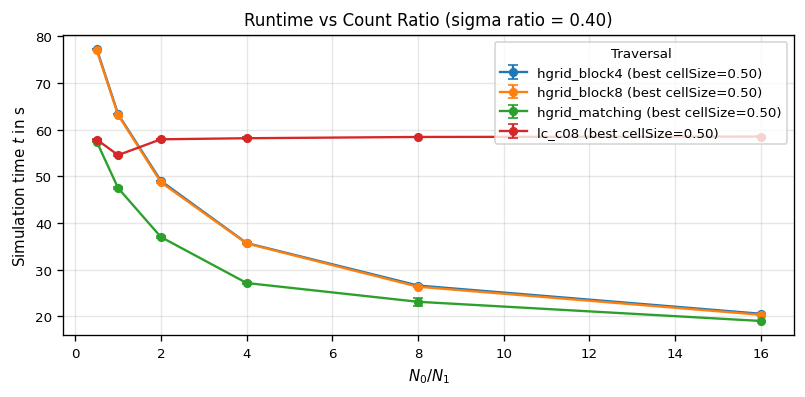

Saved: ../thesis_plots/comparison_sigma_0p40.pdf


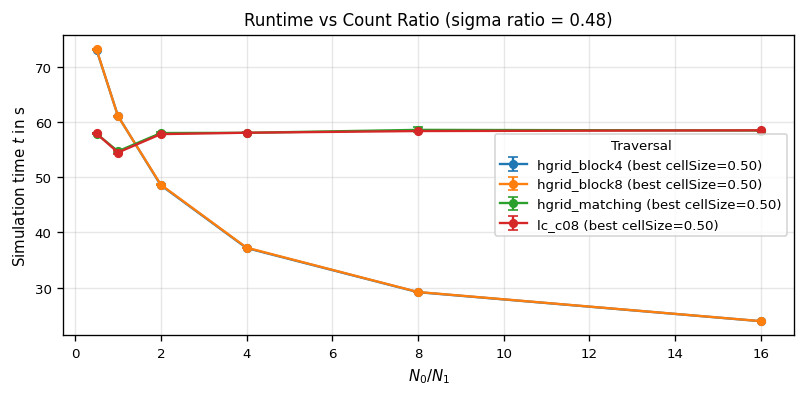

Saved: ../thesis_plots/comparison_sigma_0p48.pdf
Plotted one figure per sigma ratio with traversal lines and Student-t error bars (best cell size per traversal kept; lc_sliced and lc_c04 removed).
Cell size factors handled: [0.5, 1.0]


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats as scipy_stats
    _HAS_SCIPY = True
except Exception:
    scipy_stats = None
    _HAS_SCIPY = False


def infer_total_particles_from_input(run_dir: Path) -> int | None:
    """Infer total particles from input.yaml."""
    input_yaml = run_dir / "input.yaml"
    if not input_yaml.exists():
        return None

    total = 0
    pattern = re.compile(r"numberOfParticles\s*:\s*([0-9]+)")
    for line in input_yaml.read_text(encoding="utf-8", errors="replace").splitlines():
        m = pattern.search(line)
        if m:
            total += int(m.group(1))
    return total if total > 0 else None


def parse_prefixed_value(parts: tuple[str, ...], prefix: str) -> str | None:
    """Extract value from a path token of the form '<prefix>_<value>'."""
    token = next((p for p in parts if p.startswith(prefix)), None)
    if token is None:
        return None
    return token.split("_", 1)[1]


def collect_runtime_data(base_dir: str | Path = ".") -> pd.DataFrame:
    """Collect simulation times from logOutput files under base_dir recursively.

    Extracts cell_size_factor from the directory path if present.
    """
    base = Path(base_dir).expanduser().resolve()
    rows = []

    for log_path in base.rglob("logOutput_*.out"):
        parts = log_path.parts

        container = parse_prefixed_value(parts, "container_")
        traversal = parse_prefixed_value(parts, "traversal_")
        sigma_ratio_str = parse_prefixed_value(parts, "sigmaRatio_")
        count_ratio_str = parse_prefixed_value(parts, "countRatio_")
        run_str = parse_prefixed_value(parts, "run_")
        cell_size_str = parse_prefixed_value(parts, "cellSize_")

        if None in {container, traversal, sigma_ratio_str, count_ratio_str, run_str}:
            continue

        # Requested exclusion: skip all c04_hcp traversal variants with cell size factor 0.5
        # directly from path tokens during ingestion.
        traversal_normalized = traversal.lower()
        if "c04_hcp" in traversal_normalized and cell_size_str in {"0p5", "0p50", "0.5", "0.50"}:
            continue

        sigma_ratio = float(sigma_ratio_str.replace("p", "."))
        count_ratio = float(count_ratio_str.replace("p", "."))
        run = int(run_str)
        cell_size = float(cell_size_str.replace("p", ".")) if cell_size_str else None

        total_particles = infer_total_particles_from_input(log_path.parent)
        if total_particles is None:
            continue

        timing = read_simulation_time(log_path)
        rows.append(
            {
                "container": container,
                "traversal": traversal,
                "total_particles": total_particles,
                "sigma_ratio": sigma_ratio,
                "count_ratio": count_ratio,
                "cell_size": cell_size,
                "run": run,
                "seconds": timing["seconds"],
                "log_file": str(log_path),
            }
        )

    return pd.DataFrame(rows)


def t_critical(confidence: float, dof: int) -> float:
    """Two-sided t critical value for a given central confidence and dof."""
    if dof <= 0:
        return 0.0

    p = (1.0 + confidence) / 2.0

    if _HAS_SCIPY:
        return float(scipy_stats.t.ppf(p, dof))

    z_lookup = {
        0.68: 0.994,
        0.86: 1.080,
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576,
    }
    return z_lookup.get(round(confidence, 2), 1.96)


def apply_scrbook_11pt_style(use_latex: bool = False):
    """Style settings tuned for thesis figures included at ~\textwidth in scrbook 11pt."""
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.size": 9,
            "axes.titlesize": 10,
            "axes.labelsize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "legend.fontsize": 8,
            "legend.title_fontsize": 8,
            "lines.linewidth": 1.4,
            "lines.markersize": 4.5,
            "axes.grid": True,
            "grid.alpha": 0.3,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "text.usetex": use_latex,
        }
    )


def plot_runtime_vs_count_ratio_for_sigma(
    df: pd.DataFrame,
    sigma_ratio: float,
    ax=None,
    error_mode: str = "t86",
):
    """Plot runtime vs count ratio at one sigma ratio with one best cell size per traversal."""
    subset = df[df["sigma_ratio"].round(6).eq(round(sigma_ratio, 6))].copy()

    # Exclude traversal variants requested for plots.
    traversal_lc = subset["traversal"].str.lower()
    subset = subset[~traversal_lc.eq("lc_sliced")]
    subset = subset[~traversal_lc.str.contains("lc_c04", regex=False)]

    if subset.empty:
        raise ValueError(f"No rows found for sigma_ratio={sigma_ratio!r}.")

    summary = (
        subset.groupby(["container", "traversal", "count_ratio", "cell_size"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"), n=("seconds", "count"))
        .sort_values(["container", "traversal", "count_ratio", "cell_size"])
    )
    summary["seconds_std"] = summary["seconds_std"].fillna(0.0)

    if error_mode == "std":
        summary["error"] = summary["seconds_std"]
    else:
        confidence = 0.86 if error_mode == "t86" else 0.95
        summary["se"] = summary["seconds_std"] / summary["n"].pow(0.5)
        summary["tcrit"] = summary["n"].apply(lambda n: t_critical(confidence, int(n - 1)))
        summary["error"] = summary["tcrit"] * summary["se"]

    # For each traversal in this sigma plot, keep only the cell size with lower runtime.
    best_cell_sizes = (
        summary.groupby(["traversal", "cell_size"], as_index=False)
        .agg(mean_runtime=("seconds_mean", "mean"))
        .sort_values(["traversal", "mean_runtime", "cell_size"])
        .drop_duplicates(subset=["traversal"], keep="first")
    )[["traversal", "cell_size"]]
    summary = summary.merge(best_cell_sizes, on=["traversal", "cell_size"], how="inner")

    if ax is None:
        _, ax = plt.subplots(figsize=(6.6, 3.2), constrained_layout=True)

    traversal_order = sorted(summary["traversal"].unique().tolist())
    colors = plt.cm.tab10(range(len(traversal_order)))
    color_map = {t: colors[i] for i, t in enumerate(traversal_order)}

    # If different traversals pick different best cell sizes, reflect this via line style.
    cell_sizes = sorted(summary["cell_size"].dropna().unique().tolist())
    line_styles = ["-", "--"]
    cell_size_lines = {cs: line_styles[i % len(line_styles)] for i, cs in enumerate(cell_sizes)}

    for traversal in traversal_order:
        grp = summary[summary["traversal"] == traversal].sort_values("count_ratio")
        if grp.empty:
            continue

        cell_size = float(grp["cell_size"].iloc[0]) if pd.notna(grp["cell_size"].iloc[0]) else None
        linestyle = cell_size_lines.get(cell_size, "-")
        label = f"{traversal} (best cellSize={cell_size:.2f})" if cell_size is not None else traversal

        ax.errorbar(
            grp["count_ratio"],
            grp["seconds_mean"],
            yerr=grp["error"],
            marker="o",
            linestyle=linestyle,
            capsize=3,
            color=color_map[traversal],
            label=label,
        )

    ax.set_title(f"Runtime vs Count Ratio (sigma ratio = {sigma_ratio:.2f})")
    ax.set_xlabel(r"$N_0 / N_1$")
    ax.set_ylabel(r"Simulation time $t$ in s")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Traversal", fontsize=8)


# Collect data and generate one figure per sigma ratio
runtime_df = collect_runtime_data(".")

apply_scrbook_11pt_style(use_latex=False)

if runtime_df.empty:
    print("No logOutput_*.out files found below current directory.")
else:
    sigma_values = sorted(runtime_df["sigma_ratio"].unique().tolist())

    output_dir = Path("..") / "thesis_plots"
    output_dir.mkdir(exist_ok=True)

    for sigma in sigma_values:
        fig, ax = plt.subplots(1, 1, figsize=(6.6, 3.2), constrained_layout=True)
        plot_runtime_vs_count_ratio_for_sigma(runtime_df, sigma, ax=ax, error_mode="t86")

        sigma_tag = f"{sigma:.2f}".replace(".", "p")
        pdf_path = output_dir / f"comparison_sigma_{sigma_tag}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        plt.show()
        print(f"Saved: {pdf_path}")

    print("Plotted one figure per sigma ratio with traversal lines and Student-t error bars (best cell size per traversal kept; lc_sliced and lc_c04 removed).")
    print(f"Cell size factors handled: {sorted(runtime_df['cell_size'].dropna().unique().tolist())}")